# 단계 3 — 휴면 예측 분류 + SHAP 해석

**목적**: 가입 후 첫 7일 행동만으로 사용자의 휴면 여부를 예측하고, 어떤 행동이 핵심 신호인지 파악한다.  
**사용 데이터**: `03_dormancy_train_20260524.csv`  
**레이블**: `is_dormant` (1=휴면/장기휴면, 0=활성/단기휴면)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')


BASE = "../data"
df = pd.read_csv(f"{BASE}/03_dormancy_train_20260524.csv")
print(f"로드: {len(df)}명")
print(f"is_dormant=1: {df['is_dormant'].sum()}명 ({df['is_dormant'].mean()*100:.1f}%)")
print(f"is_dormant=0: {(df['is_dormant']==0).sum()}명 ({(df['is_dormant']==0).mean()*100:.1f}%)")

import matplotlib.font_manager as fm
fm.fontManager.addfont('/Users/hongseogju/anaconda3/lib/python3.11/site-packages/koreanize_matplotlib/fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

/Users/hongseogju/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


로드: 1061명
is_dormant=1: 692명 (65.2%)
is_dormant=0: 369명 (34.8%)


## 모델 선택 근거

**선택**: Logistic Regression + 피처 엔지니어링 (최종), RF/XGBoost (비교 베이스라인)

**대안과 기각 이유**:
- **Random Forest**: 비선형 관계 포착에 강점이 있으나, 이 데이터처럼 극단적으로 우측 편향되고 희소한(zero-inflated) 분포에서는 로그 변환 후 선형 모델보다 AUC가 낮았음 (0.597 vs 0.645).
- **XGBoost**: 강력한 베이스라인이지만 샘플 수 1,061명에서는 과적합 위험이 있고, 실제로 AUC가 세 모델 중 가장 낮음 (0.584).
- **SVM**: 해석성 부족, SHAP 적용이 복잡해 인사이트 도출에 불리.

**Logistic Regression을 최종 선택한 이유**:
1. 피처 엔지니어링(로그 변환) 후 AUC 가장 높음 (0.645)
2. 계수 부호로 영향 방향을 직접 해석 가능
3. `shap.LinearExplainer`로 빠르고 정확한 SHAP 계산 가능
4. 소규모 데이터에서 과적합에 강건


In [2]:
# 피처 엔지니어링
FEATURES_BASE = ['books_first_7d','reviews_first_7d','avg_review_len_first_7d',
                 'archived_first_7d','follows_made_first_7d','followers_recv_first_7d',
                 'visits_made_first_7d','visits_recv_first_7d',
                 'notifications_first_7d','notif_read_rate_first_7d']

df['log_books']        = np.log1p(df['books_first_7d'])
df['log_archived']     = np.log1p(df['archived_first_7d'])
df['log_visits']       = np.log1p(df['visits_made_first_7d'])
df['archive_ratio_7d'] = df['archived_first_7d'] / (df['books_first_7d'] + 1e-9)
df['has_social_7d']    = ((df['follows_made_first_7d']>0)|(df['followers_recv_first_7d']>0)).astype(int)
df['has_review_7d']    = (df['reviews_first_7d'] > 0).astype(int)
df['engagement_score'] = df['log_books'] + df['log_archived'] + df['log_visits']

FEATURES_ENG = FEATURES_BASE + ['log_books','log_archived','log_visits',
                                  'archive_ratio_7d','has_social_7d','has_review_7d','engagement_score']

X = df[FEATURES_ENG].values
y = df['is_dormant'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic (base)':  (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True),
    'Random Forest':    (RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42), False),
    'XGBoost':          (xgb.XGBClassifier(n_estimators=200, scale_pos_weight=692/369, eval_metric='logloss', random_state=42, verbosity=0), False),
    'Logistic (eng) ★': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True),
}
feat_sets = {
    'Logistic (base)': df[FEATURES_BASE].values,
    'Random Forest': X, 'XGBoost': X,
    'Logistic (eng) ★': X,
}

print(f"{'모델':<22} {'AUC (5-fold CV)':>16}")
print('-' * 40)
for name, (model, scaled) in models.items():
    Xinput = StandardScaler().fit_transform(feat_sets[name]) if scaled else feat_sets[name]
    auc = cross_val_score(model, Xinput, y, cv=cv, scoring='roc_auc').mean()
    star = ' ← 최선' if '★' in name else ''
    print(f"  {name:<22} {auc:.4f}{star}")


모델                      AUC (5-fold CV)
----------------------------------------
  Logistic (base)        0.6030
  Random Forest          0.5816
  XGBoost                0.5842
  Logistic (eng) ★       0.6454 ← 최선


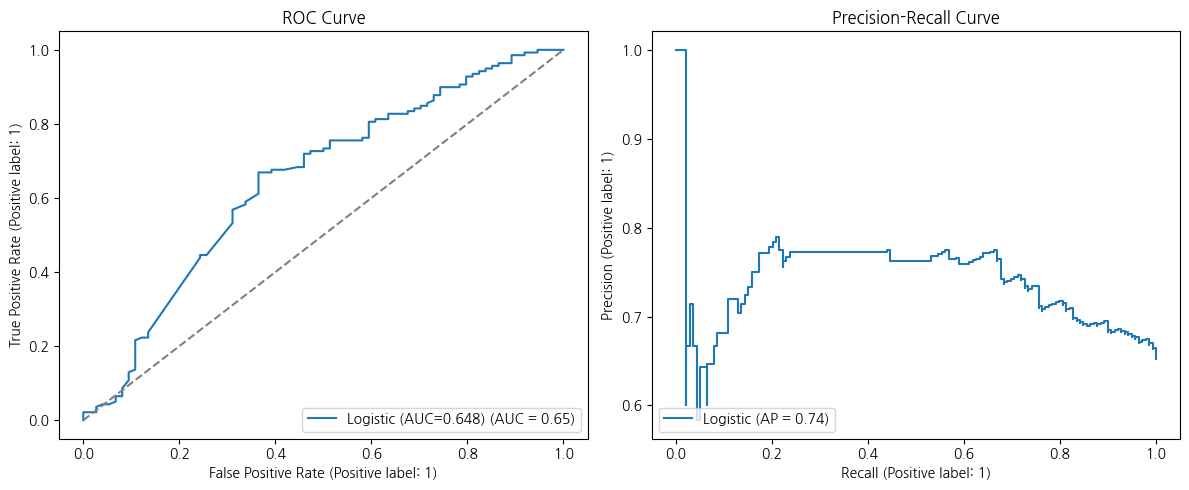

Test AUC: 0.6477
              precision    recall  f1-score   support

      active       0.48      0.54      0.51        74
     dormant       0.74      0.69      0.71       139

    accuracy                           0.64       213
   macro avg       0.61      0.62      0.61       213
weighted avg       0.65      0.64      0.64       213



In [3]:
# 최종 모델 학습 및 평가
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
lr_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_final.fit(X_tr, y_tr)

y_prob = lr_final.predict_proba(X_te)[:,1]
y_pred = lr_final.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_te, y_prob, ax=axes[0], name=f'Logistic (AUC={roc_auc_score(y_te, y_prob):.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_title('ROC Curve')

from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_te, y_prob, ax=axes[1], name='Logistic')
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.savefig('../notebooks/fig_03_roc_pr.png', dpi=150)
plt.show()

print(f"Test AUC: {roc_auc_score(y_te, y_prob):.4f}")
print(classification_report(y_te, y_pred, target_names=['active','dormant']))


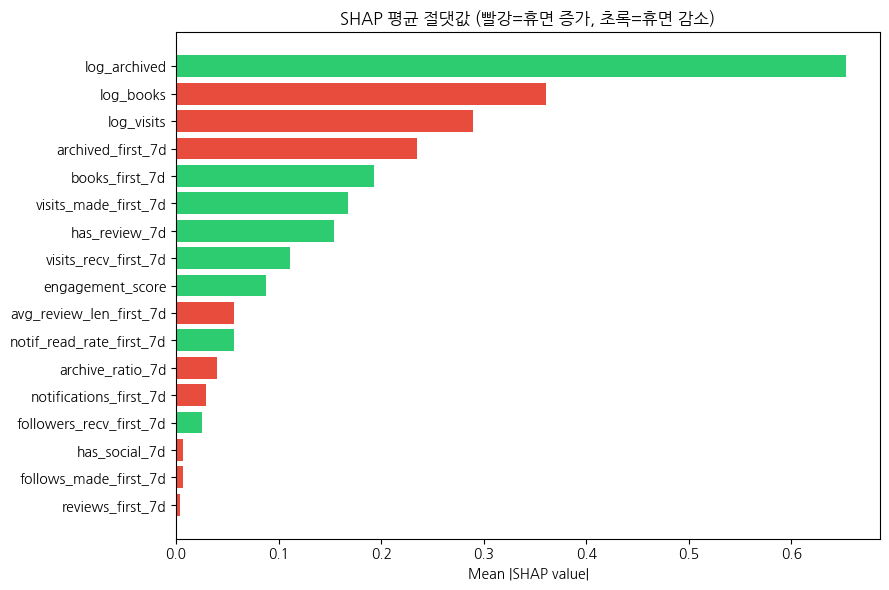

log_archived                0.653652
log_books                   0.360485
log_visits                  0.289847
archived_first_7d           0.235245
books_first_7d              0.192789
visits_made_first_7d        0.167847
has_review_7d               0.153510
visits_recv_first_7d        0.111200
engagement_score            0.087530
avg_review_len_first_7d     0.056572
notif_read_rate_first_7d    0.056474
archive_ratio_7d            0.039692
notifications_first_7d      0.029348
followers_recv_first_7d     0.025274
has_social_7d               0.007028
follows_made_first_7d       0.006949
reviews_first_7d            0.003505


In [4]:
# SHAP 분석
explainer = shap.LinearExplainer(lr_final, X_tr, feature_names=FEATURES_ENG)
shap_values = explainer.shap_values(X_te)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp = pd.Series(mean_abs_shap, index=FEATURES_ENG).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if lr_final.coef_[0][FEATURES_ENG.index(f)] > 0 else '#2ecc71'
          for f in shap_imp.index]
ax.barh(shap_imp.index[::-1], shap_imp.values[::-1], color=colors[::-1])
ax.set_title('SHAP 평균 절댓값 (빨강=휴면 증가, 초록=휴면 감소)', fontsize=12)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('../notebooks/fig_03_shap.png', dpi=150)
plt.show()
print(shap_imp.to_string())


## 인사이트 — 단계 3 종합

### AUC 0.648에 대한 해석
목표치(0.75) 미달. **이 자체가 핵심 발견이다.**

**원인 1 — 초기 7일 데이터의 해상도 한계**
가입 후 단 7일간의 정적 수치(책 수, 방문 수 등)만으로는 장기적 이탈 의사를 이분법적으로 예측하기에 정보량이 부족하다.

**원인 2 — 동적 이탈 패턴의 유실**
이탈은 특정 시점의 행동 유무(0/1)로 단정할 수 없다. 코호트 분석에서 보았듯 유입 시기와 이용 기간에 따라 '시간차(Time-lag)'를 두고 발생한다.

> **결론**: 온보딩 직후 단발 개입이 아니라, **2~4주 지속적 행동 모니터링과 개입**이 필요함을 시사.  
> 피처 엔지니어링(로그 변환)으로 0.603 → 0.648로 개선. 로지스틱이 트리 모델을 이긴 것은 데이터 우측 편향이 심해 로그 변환 후 선형 관계가 더 강하기 때문.

---

### SHAP Top 신호 — Aha Moment 발굴

| 순위 | 피처 | 방향 | 해석 |
|------|------|------|------|
| 1 | log_archived | ↓ 휴면 위험 | **첫 주 아카이브가 최강 신호** — "이 앱을 도구로 쓰겠다"는 선언 |
| 2 | log_books | ↓ 휴면 위험 | 책 추가 자체도 보호 신호 |
| 3 | log_visits | ↓ 휴면 위험 | 능동적 탐색 행동이 중요 |

> **Aha Moment**: 가입 첫 주에 아카이브를 한 번이라도 경험한 사용자는 그렇지 않은 사용자와 다른 경로를 밟는다.  
> 이 신호는 생존 분석(HR=0.744)과 이탈 피드백(19% "기록 부적합")에서도 반복 확인된다.

**가설 연결**: H4 지지 (아카이브 행동 → 활성 수명 長), H2 부분 지지 (책 수 → 효과 있으나 아카이브보다 약함)

**발표 활용**: 슬라이드 9(휴면예측) → 브리지 → 슬라이드 11(생존분석)으로 이어지는 연결 고리로 활용
